## Moose 

https://github.com/MooseNeuro/moose-notebooks/blob/main/Getting_started_with_compartmental_modelling_in_MOOSE.ipynb

In [1]:
import moose
import numpy as np
import matplotlib.pyplot as plt

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [4]:

data = moose.Neutral('/data')
model = moose.Neutral('/model')

In [5]:

compartment = moose.Compartment('/model/compartment')

In [6]:
moose.getFieldNames('Compartment')

['Cm',
 'Em',
 'Im',
 'Ra',
 'Rm',
 'Vm',
 'VmOut',
 'axial',
 'axialOut',
 'cable',
 'channel',
 'childOut',
 'children',
 'className',
 'coords',
 'destFields',
 'diameter',
 'displace',
 'dt',
 'fieldIndex',
 'getChildren',
 'getClassName',
 'getCm',
 'getCoords',
 'getDestFields',
 'getDiameter',
 'getDt',
 'getEm',
 'getFieldIndex',
 'getIdValue',
 'getIm',
 'getIndex',
 'getInitVm',
 'getInject',
 'getIsA',
 'getLength',
 'getMe',
 'getMsgDestFunctions',
 'getMsgDests',
 'getMsgIn',
 'getMsgOut',
 'getName',
 'getNeighbors',
 'getNumData',
 'getNumField',
 'getParent',
 'getPath',
 'getRa',
 'getRm',
 'getSourceFields',
 'getThis',
 'getTick',
 'getValueFields',
 'getVm',
 'getX',
 'getX0',
 'getY',
 'getY0',
 'getZ',
 'getZ0',
 'handleAxial',
 'handleChannel',
 'handleRaxial',
 'idValue',
 'index',
 'init',
 'initProc',
 'initReinit',
 'initVm',
 'inject',
 'injectMsg',
 'isA',
 'length',
 'me',
 'msgDestFunctions',
 'msgDests',
 'msgIn',
 'msgOut',
 'name',
 'neighbors',
 'noti

In [7]:
compartment.valueFields

['this',
 'name',
 'me',
 'parent',
 'children',
 'path',
 'className',
 'numData',
 'numField',
 'idValue',
 'index',
 'fieldIndex',
 'tick',
 'dt',
 'valueFields',
 'sourceFields',
 'destFields',
 'msgOut',
 'msgIn',
 'Vm',
 'Cm',
 'Em',
 'Im',
 'inject',
 'initVm',
 'Rm',
 'Ra',
 'diameter',
 'length',
 'x0',
 'y0',
 'z0',
 'x',
 'y',
 'z',
 'coords']

In [8]:
moose.showfield(compartment)


[/model[0]/compartment[0]]
name          = compartment
className     = Compartment
tick          = 3
dt            = 5e-05
Cm            = 1.0
Em            = -0.06
Im            = 0.0
Ra            = 1.0
Rm            = 1.0
Vm            = -0.06
diameter      = 0.0
initVm        = -0.06
inject        = 0.0
length        = 0.0
x             = 0.0
x0            = 0.0
y             = 0.0
y0            = 0.0
z             = 0.0
z0            = 0.0



In [9]:
compartment.initVm = -70e-3
compartment.Rm = 1e4
compartment.Cm = 1e-7
compartment.inject = 1e-6


In [10]:

vm_tab = moose.Table('/data/Vm')
moose.connect(vm_tab, 'requestOut', compartment, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[0] id=5 dataIndex=0 fieldIndex=0>

In [11]:

runtime = 10e-3  # simulate 10 ms
moose.reinit()
moose.start(runtime)

In [14]:

print('compartment dt',compartment.dt)
print('table dt',vm_tab.dt)

compartment dt 5e-05
table dt 0.0001


<class 'numpy.ndarray'> (101,) float64


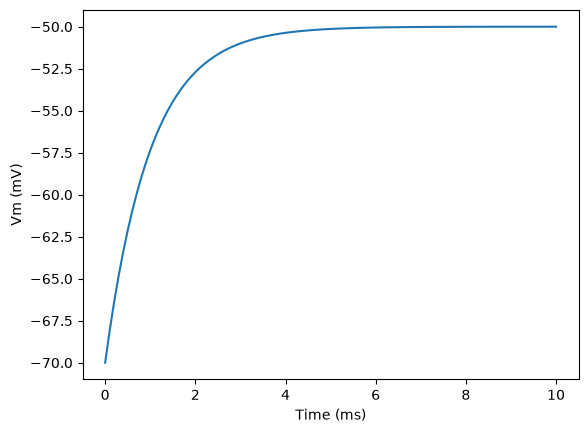

In [15]:
Vm = np.array(vm_tab.vector, dtype=np.float64, copy=True)
dt = float(vm_tab.dt)

t = np.arange(Vm.size, dtype=np.float64) * dt

print(type(Vm), Vm.shape, Vm.dtype)

plt.figure()
plt.plot(t * 1e3, Vm * 1e3)
plt.xlabel("Time (ms)")
plt.ylabel("Vm (mV)")
plt.show()